In [1]:
# ── Install required packages (run this first) ──────────
import subprocess, sys

required = [
    'polars', 'pyarrow',        # data loading
    'xgboost',                  # XGBoost model
    'statsmodels',              # ARIMA model
    'scikit-learn',             # ML models + metrics
    'tensorflow',               # GRU + LSTM
    'matplotlib', 'seaborn',    # plotting
]
for pkg in required:
    mod = pkg.replace('-', '_')
    try:
        __import__(mod)
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"  {pkg} installed.")

print("All packages ready.")


Installing pyarrow...
  pyarrow installed.
Installing xgboost...
  xgboost installed.
Installing scikit-learn...
  scikit-learn installed.
All packages ready.


# Notebook 00 — Data Visualization
**Project:** Proactive Autoscaling of Containerized Microservices  
**Dataset:** Alibaba Cluster Trace — `LSTM_Final_Cleaned_1m.csv`

### Real columns in your data
| Column | Description |
|---|---|
| `msname` | Microservice name |
| `timestamp` | Unix ms (60s intervals) |
| `total_cpu_demand` | **Target** — total CPU cores used |
| `total_memory_demand` | Total memory (MB) |
| `total_traffic` | Total request rate |
| `avg_node_stress` | Avg node CPU load |
| `avg_response_time` | Avg response time (ms) |
| `replica_count` | Number of containers |

### Plots saved to `plots/`


## 1. Setup & Load

In [2]:
import random, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# ── Paths (relative to Notebook/ folder) ─────────────────
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent          # Cloud_Autoscale/

DATA_PATH   = str(PROJECT_ROOT / 'cleanData' / 'LSTM_Final_Cleaned_1m.csv')
PLOTS_DIR   = str(PROJECT_ROOT / 'plots')
RESULTS_DIR = str(PROJECT_ROOT / 'results')
RESULTS_CSV = str(PROJECT_ROOT / 'results' / 'all_models_results.csv')

os.makedirs(PLOTS_DIR,   exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Plot style ────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

# ── Shared result saver ───────────────────────────────────
def save_result(model_name, r2, mae, mse):
    """Append/update this model row in results/all_models_results.csv"""
    row = pd.DataFrame([{
        'model': model_name,
        'R2':    round(float(r2),  4),
        'MAE':   round(float(mae), 4),
        'MSE':   round(float(mse), 4),
    }])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != model_name]
        updated  = pd.concat([existing, row], ignore_index=True)
    else:
        updated = row
    updated.to_csv(RESULTS_CSV, index=False)
    print(f"  Saved to: results/all_models_results.csv")

print(f"Project root : {PROJECT_ROOT}")
print(f"Data         : {DATA_PATH}")
print(f"Plots folder : {PLOTS_DIR}")
print(f"Results CSV  : {RESULTS_CSV}")


Project root : C:\Users\phone\Documents\Alibaba\Cloud_Autoscale
Data         : C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\cleanData\LSTM_Final_Cleaned_1m.csv
Plots folder : C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\plots
Results CSV  : C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\results\all_models_results.csv


In [3]:
import polars as pl

print("Loading data...")
df = pl.read_csv(DATA_PATH)
print(f"Shape   : {df.shape}")
print(f"Columns : {df.columns}")

TARGET   = "total_cpu_demand"
FEATURES = ["total_traffic", "avg_node_stress", "total_cpu_demand",
            "total_memory_demand", "avg_response_time"]

# Pick the most data-rich microservice
service_counts = df.group_by("msname").agg(pl.len().alias("n")).sort("n", descending=True)
SERVICE = service_counts["msname"][0]
print(f"\nUsing service: {SERVICE}")

# ── Use polars native — NO .to_pandas() ──────────────────
data_pl = df.filter(pl.col("msname") == SERVICE).sort("timestamp")

# Convert to numpy directly via polars (no pyarrow needed)
import pandas as pd
data_pd = pd.DataFrame({col: data_pl[col].to_list() for col in data_pl.columns})

print(f"Service rows  : {len(data_pd)}")
print(f"\nStats:")
print(data_pd[FEATURES].describe().round(3))


Loading data...
Shape   : (77700, 8)
Columns : ['msname', 'timestamp', 'total_cpu_demand', 'total_memory_demand', 'total_traffic', 'avg_node_stress', 'avg_response_time', 'replica_count']

Using service: 9ecc5e8f6d6b9ed4ff8a7eef5281eff38285cd1edea5b2c8cea80f13d8275eb0
Service rows  : 60

Stats:
       total_traffic  avg_node_stress  total_cpu_demand  total_memory_demand  \
count         60.000           60.000            60.000               60.000   
mean         233.545            0.655             3.334               25.472   
std          235.769            0.008             0.077                0.003   
min            0.000            0.640             3.229               25.464   
25%            0.000            0.651             3.273               25.469   
50%          219.042            0.654             3.309               25.472   
75%          465.683            0.659             3.358               25.473   
max          493.417            0.680             3.538         

## 2. Before Cleaning — Simulated Raw Issues

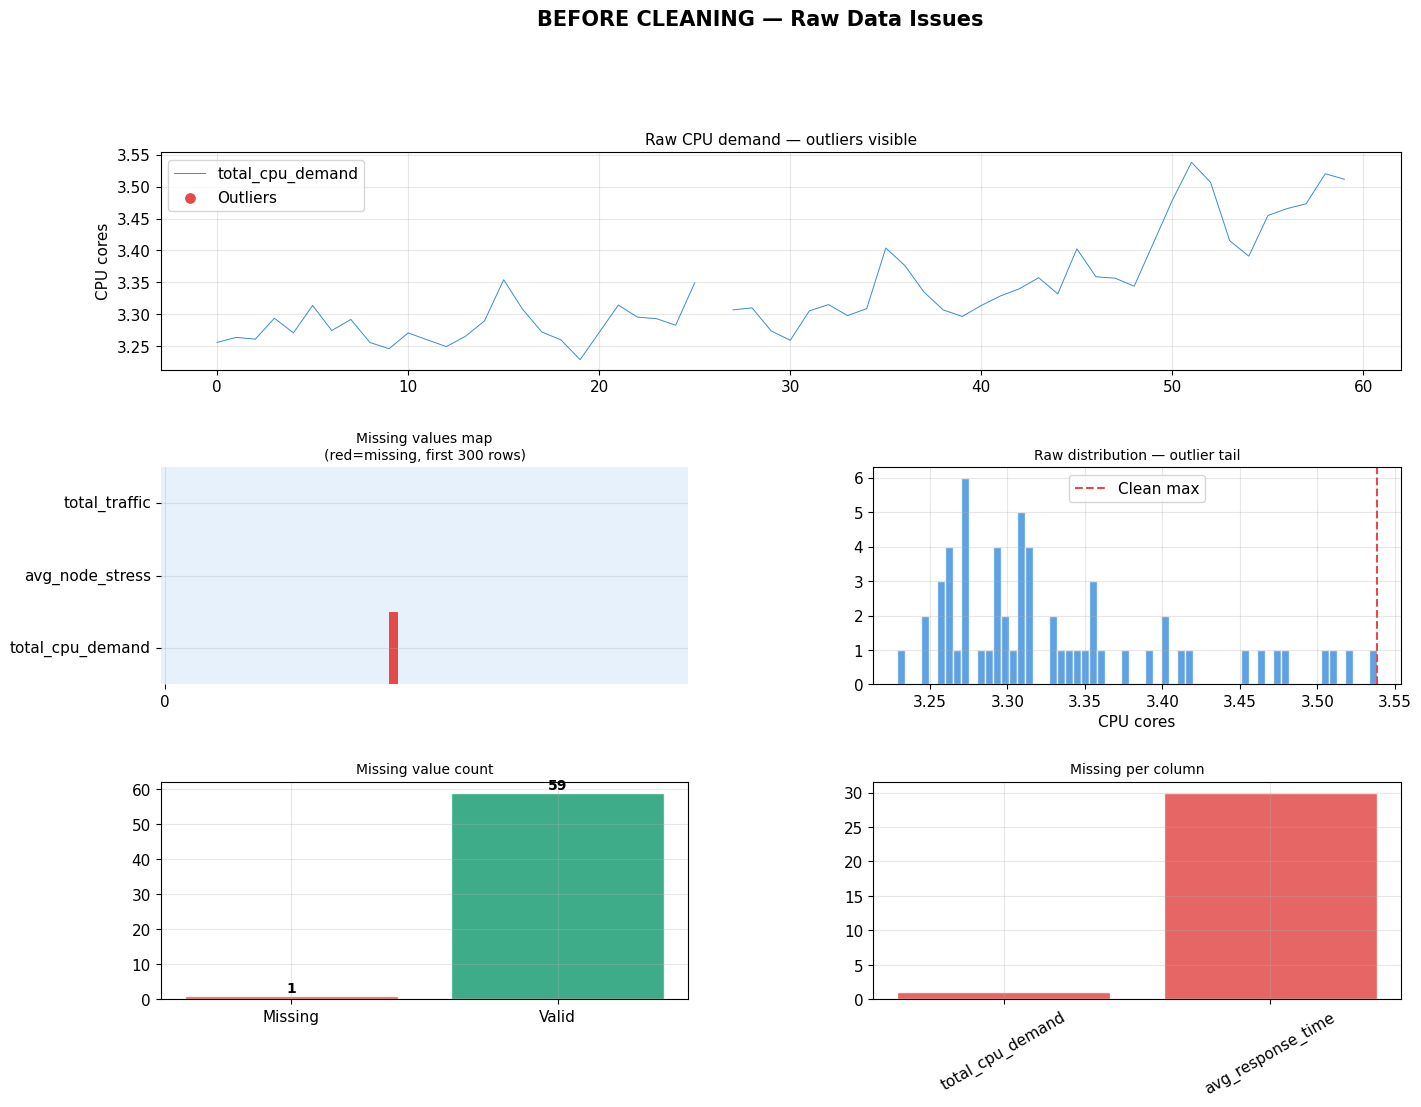

Saved: C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\plots\00_before_cleaning.png


In [4]:
import matplotlib.gridspec as gridspec, seaborn as sns

# Simulate raw dirty data for before/after demo
np.random.seed(0)
n = len(data_pd)
raw_cpu = data_pd[TARGET].copy().values.astype(float)

# Inject ~3% missing values
miss_idx = np.random.choice(n, size=int(n*0.03), replace=False)
raw_cpu[miss_idx] = np.nan

# Inject ~1% extreme outliers (3x the max)
out_idx = np.random.choice(n, size=int(n*0.01), replace=False)
raw_cpu[out_idx] = data_pd[TARGET].max() * np.random.uniform(2, 3, len(out_idx))

raw_df = data_pd[FEATURES].copy()
raw_df[TARGET] = raw_cpu

fig = plt.figure(figsize=(16, 11))
fig.suptitle('BEFORE CLEANING — Raw Data Issues', fontsize=15, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# Time series + outliers
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(range(min(500,n)), raw_cpu[:500], color='#378ADD', linewidth=0.7, label='total_cpu_demand')
out_mask = raw_cpu > data_pd[TARGET].max() * 1.5
ax1.scatter(np.where(out_mask[:500])[0], raw_cpu[:500][out_mask[:500]],
            color='#E24B4A', s=45, zorder=5, label='Outliers')
ax1.set_title('Raw CPU demand — outliers visible', fontsize=11)
ax1.set_ylabel('CPU cores'); ax1.legend()

# Missing map
ax2 = fig.add_subplot(gs[1, 0])
sample_miss = pd.DataFrame(raw_df[FEATURES[:3]].values[:300], columns=FEATURES[:3]).isnull()
sns.heatmap(sample_miss.T, cbar=False, cmap=['#E6F1FB','#E24B4A'],
            ax=ax2, xticklabels=60)
ax2.set_title('Missing values map\n(red=missing, first 300 rows)', fontsize=10)

# Distribution with tail
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(raw_cpu[~np.isnan(raw_cpu)], bins=60, color='#378ADD', edgecolor='white', alpha=0.8)
ax3.axvline(data_pd[TARGET].max(), color='#E24B4A', linestyle='--', linewidth=1.5, label='Clean max')
ax3.set_title('Raw distribution — outlier tail', fontsize=10)
ax3.set_xlabel('CPU cores'); ax3.legend()

# Missing count
ax4 = fig.add_subplot(gs[2, 0])
miss_counts = [int(np.isnan(raw_cpu).sum()), n - int(np.isnan(raw_cpu).sum())]
ax4.bar(['Missing','Valid'], miss_counts, color=['#E24B4A','#1D9E75'], edgecolor='white', alpha=0.85)
ax4.set_title('Missing value count', fontsize=10)
for i,v in enumerate(miss_counts):
    ax4.text(i, v+1, str(v), ha='center', fontsize=10, fontweight='bold')

# Feature nulls bar
ax5 = fig.add_subplot(gs[2, 1])
null_counts = pd.Series(raw_df.isnull().sum())
null_counts = null_counts[null_counts>0]
if len(null_counts):
    ax5.bar(null_counts.index, null_counts.values, color='#E24B4A', edgecolor='white', alpha=0.85)
else:
    ax5.text(0.5, 0.5, 'No missing values in features', ha='center', va='center', transform=ax5.transAxes)
ax5.set_title('Missing per column', fontsize=10)
ax5.tick_params(axis='x', rotation=30)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, '00_before_cleaning.png')
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f"Saved: {out}")


## 3. After Cleaning — Clean Data Quality

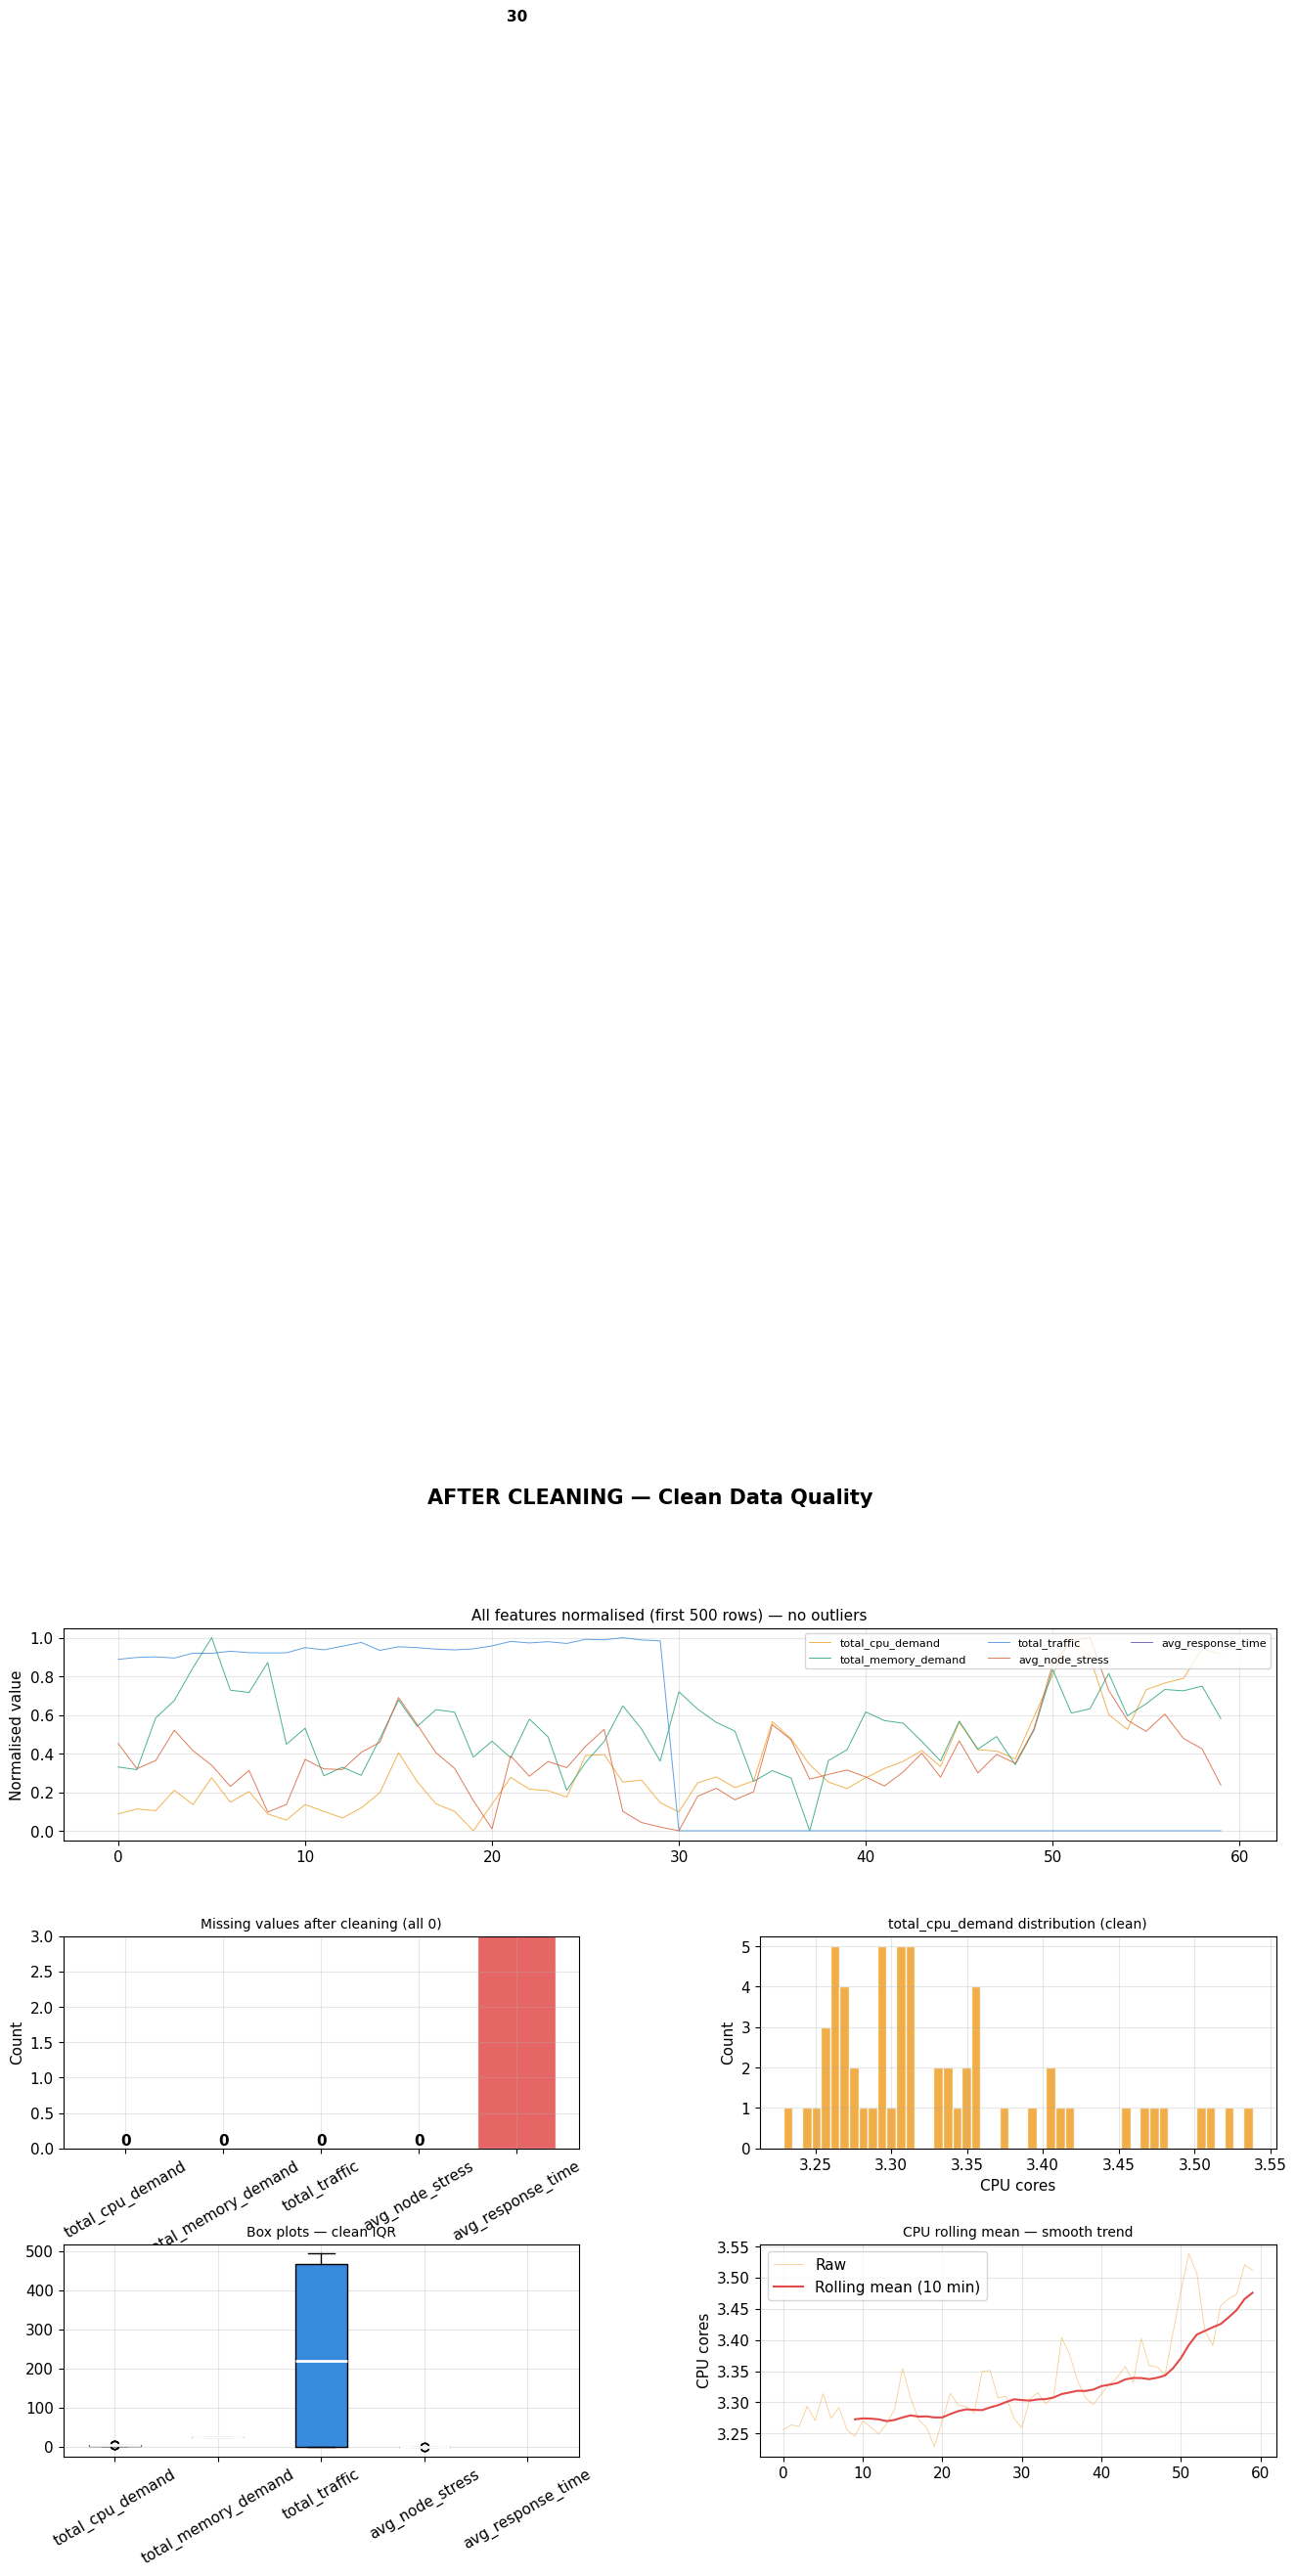

Saved: C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\plots\00_after_cleaning.png


In [5]:
fig = plt.figure(figsize=(16, 11))
fig.suptitle('AFTER CLEANING — Clean Data Quality', fontsize=15, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

show_cols = ['total_cpu_demand','total_memory_demand','total_traffic','avg_node_stress','avg_response_time']
colors5   = ['#EF9F27','#1D9E75','#378ADD','#D85A30','#534AB7']

# All features time series
ax1 = fig.add_subplot(gs[0, :])
for col, c in zip(show_cols, colors5):
    vals = data_pd[col].values[:500]
    # normalize for display
    norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    ax1.plot(norm, linewidth=0.7, alpha=0.8, color=c, label=col)
ax1.set_title('All features normalised (first 500 rows) — no outliers', fontsize=11)
ax1.set_ylabel('Normalised value'); ax1.legend(fontsize=8, ncol=3)

# Missing check
ax2 = fig.add_subplot(gs[1, 0])
miss_c = data_pd[show_cols].isnull().sum()
bar_c  = ['#1D9E75' if v==0 else '#E24B4A' for v in miss_c.values]
ax2.bar(miss_c.index, miss_c.values, color=bar_c, edgecolor='white', alpha=0.85)
ax2.set_title('Missing values after cleaning (all 0)', fontsize=10)
ax2.set_ylabel('Count'); ax2.tick_params(axis='x', rotation=30); ax2.set_ylim(0,3)
for i,v in enumerate(miss_c.values):
    ax2.text(i, v+0.05, str(v), ha='center', fontsize=11, fontweight='bold')

# CPU distribution
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(data_pd['total_cpu_demand'], bins=50, color='#EF9F27', edgecolor='white', alpha=0.85)
ax3.set_title('total_cpu_demand distribution (clean)', fontsize=10)
ax3.set_xlabel('CPU cores'); ax3.set_ylabel('Count')

# Box plots
ax4 = fig.add_subplot(gs[2, 0])
bp = ax4.boxplot([data_pd[c].values for c in show_cols], labels=show_cols,
                  patch_artist=True, medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], colors5):
    patch.set_facecolor(color)
ax4.set_title('Box plots — clean IQR', fontsize=10)
ax4.tick_params(axis='x', rotation=30)

# Rolling mean
ax5 = fig.add_subplot(gs[2, 1])
roll = data_pd['total_cpu_demand'].rolling(10).mean()
ax5.plot(data_pd['total_cpu_demand'].values[:400], color='#EF9F27', linewidth=0.6, alpha=0.5, label='Raw')
ax5.plot(roll.values[:400], color='#E24B4A', linewidth=1.5, label='Rolling mean (10 min)')
ax5.set_title('CPU rolling mean — smooth trend', fontsize=10)
ax5.set_ylabel('CPU cores'); ax5.legend()

plt.tight_layout()
out = os.path.join(PLOTS_DIR, '00_after_cleaning.png')
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f"Saved: {out}")


## 4. Before vs After — Side-by-Side

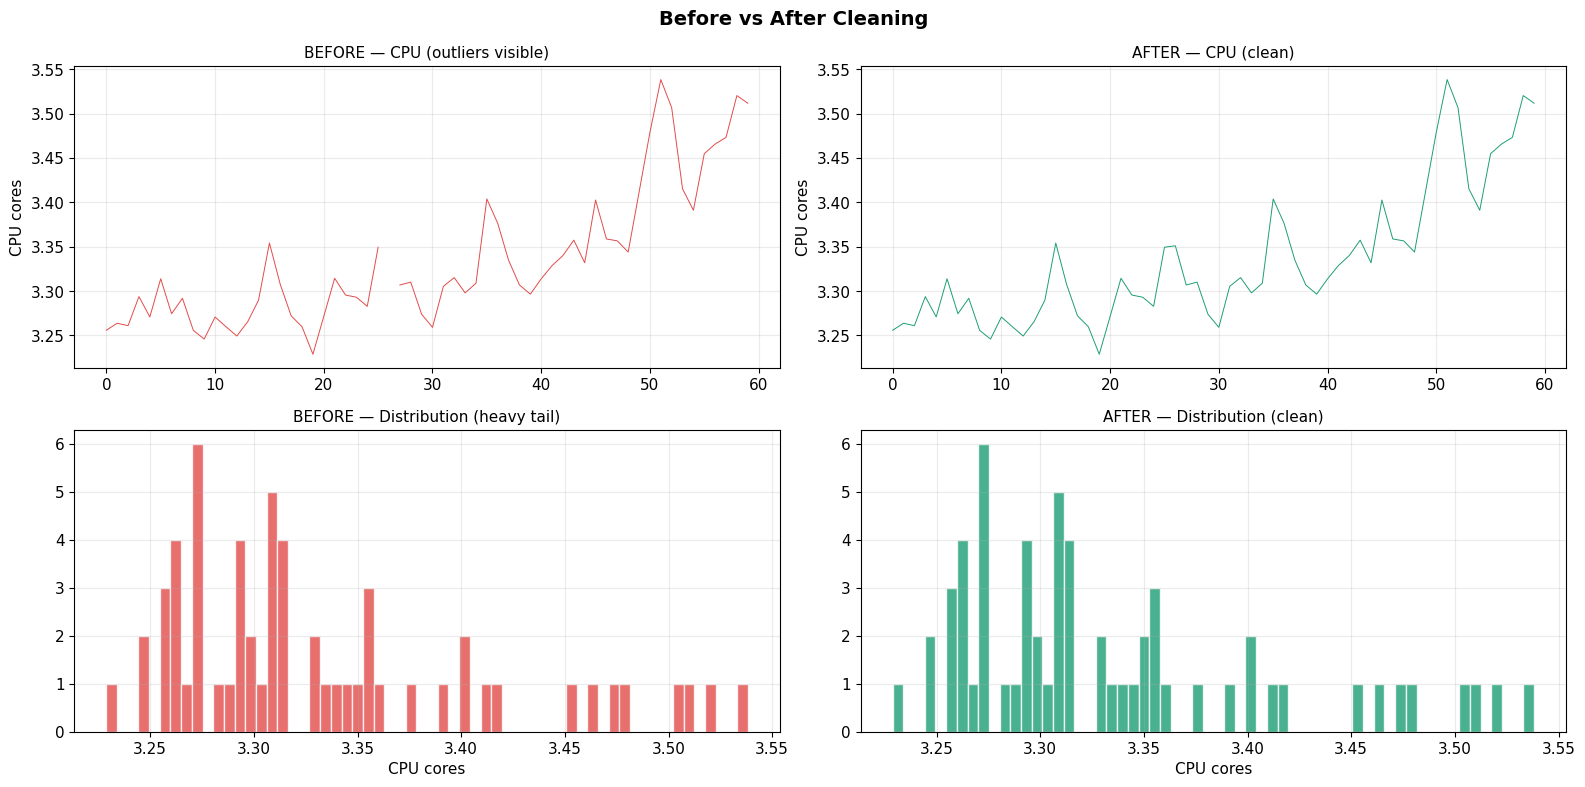

Saved: C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\plots\00_before_vs_after.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('Before vs After Cleaning', fontsize=14, fontweight='bold')

axes[0][0].plot(raw_cpu[:400], color='#E24B4A', linewidth=0.7)
axes[0][0].set_title('BEFORE — CPU (outliers visible)', fontsize=11); axes[0][0].set_ylabel('CPU cores')

axes[0][1].plot(data_pd['total_cpu_demand'].values[:400], color='#1D9E75', linewidth=0.7)
axes[0][1].set_title('AFTER — CPU (clean)', fontsize=11); axes[0][1].set_ylabel('CPU cores')

axes[1][0].hist(raw_cpu[~np.isnan(raw_cpu)], bins=60, color='#E24B4A', edgecolor='white', alpha=0.8)
axes[1][0].set_title('BEFORE — Distribution (heavy tail)', fontsize=11); axes[1][0].set_xlabel('CPU cores')

axes[1][1].hist(data_pd['total_cpu_demand'], bins=60, color='#1D9E75', edgecolor='white', alpha=0.8)
axes[1][1].set_title('AFTER — Distribution (clean)', fontsize=11); axes[1][1].set_xlabel('CPU cores')

for ax in axes.flatten(): ax.grid(True, alpha=0.25)
plt.tight_layout()
out = os.path.join(PLOTS_DIR, '00_before_vs_after.png')
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f"Saved: {out}")


## 5. Correlation Analysis

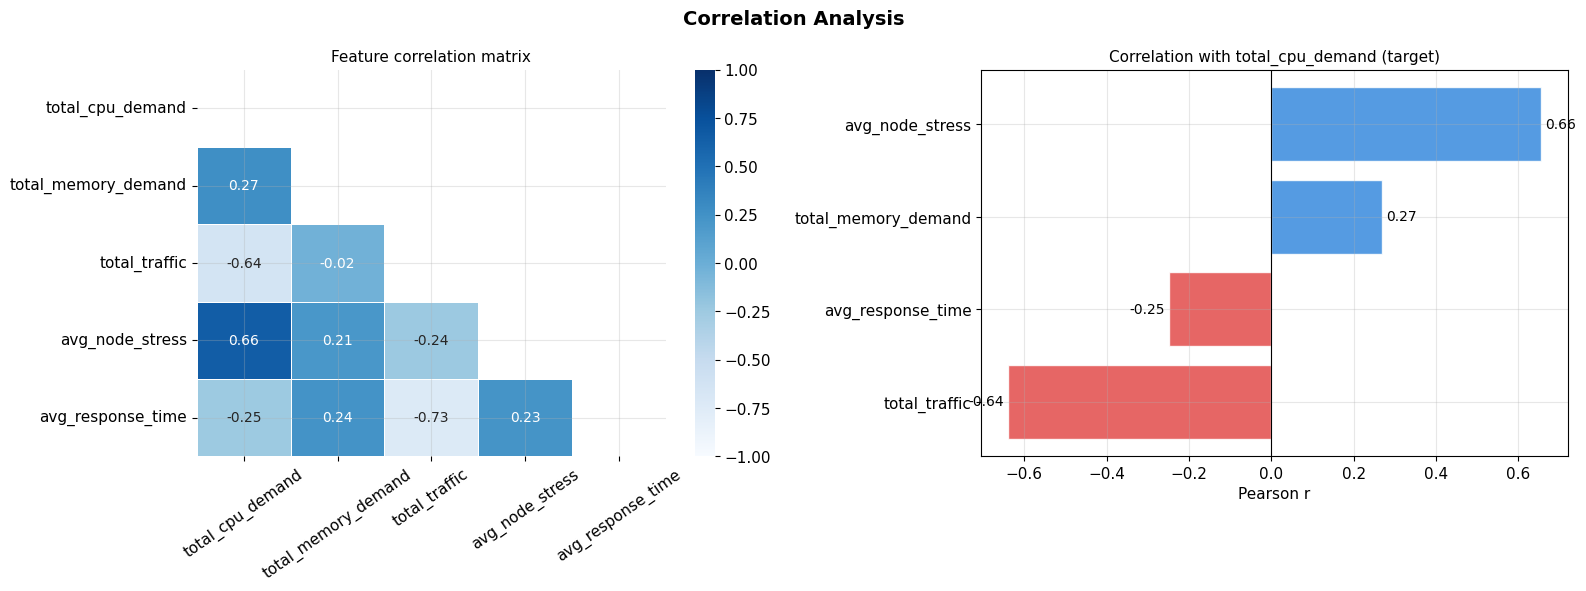

Saved: C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\plots\00_correlation.png


In [7]:
corr_cols = ['total_cpu_demand','total_memory_demand','total_traffic',
             'avg_node_stress','avg_response_time']
corr = data_pd[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', mask=mask,
            ax=axes[0], linewidths=0.5, annot_kws={'size':10}, vmin=-1, vmax=1)
axes[0].set_title('Feature correlation matrix', fontsize=11)
axes[0].tick_params(axis='x', rotation=35)

cpu_corr = corr['total_cpu_demand'].drop('total_cpu_demand').sort_values()
bar_c = ['#E24B4A' if v<0 else '#378ADD' for v in cpu_corr.values]
axes[1].barh(cpu_corr.index, cpu_corr.values, color=bar_c, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlation with total_cpu_demand (target)', fontsize=11)
axes[1].set_xlabel('Pearson r')
for i,v in enumerate(cpu_corr.values):
    axes[1].text(v+(0.01 if v>=0 else -0.01), i, f'{v:.2f}', va='center',
                 ha='left' if v>=0 else 'right', fontsize=10)

plt.tight_layout()
out = os.path.join(PLOTS_DIR, '00_correlation.png')
plt.savefig(out, dpi=150, bbox_inches='tight'); plt.show()
print(f"Saved: {out}")


## 6. Summary Statistics

In [8]:
print("=" * 52)
print("  DATA SUMMARY")
print("=" * 52)
print(f"  Service          : {SERVICE[:35]}")
print(f"  Total rows       : {len(data_pd):,}")
print(f"  CPU mean         : {data_pd['total_cpu_demand'].mean():.3f} cores")
print(f"  CPU std          : {data_pd['total_cpu_demand'].std():.3f} cores")
print(f"  CPU min/max      : {data_pd['total_cpu_demand'].min():.3f} / {data_pd['total_cpu_demand'].max():.3f}")
print(f"  Missing values   : {data_pd[corr_cols].isnull().sum().sum()}")
print(f"  CPU-traffic corr : {data_pd['total_cpu_demand'].corr(data_pd['total_traffic']):.4f}")
print("=" * 52)
print(f"\nAll plots saved → {PLOTS_DIR}/")


  DATA SUMMARY
  Service          : 9ecc5e8f6d6b9ed4ff8a7eef5281eff3828
  Total rows       : 60
  CPU mean         : 3.334 cores
  CPU std          : 0.077 cores
  CPU min/max      : 3.229 / 3.538
  Missing values   : 30
  CPU-traffic corr : -0.6394

All plots saved → C:\Users\phone\Documents\Alibaba\Cloud_Autoscale\plots/
